In [1]:
# Tự nạp lại raw_feature.py mỗi khi sửa, không cần restart kernel
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from feature_node import build_entity_features, load_data

In [2]:
df=load_data()
asof, log_cols = build_entity_features(df)
feat = asof[asof["split"] == "train"].drop(columns=["split", "ori_idx"])
print("feat shape:", feat.shape)

feat shape: (3046861, 63)


In [3]:
# Profile mọi cột để TỰ quyết định nhóm (thay cho việc hardcode ratio_cols/special)
profile = pd.DataFrame({
    "min":     feat.min(),
    "max":     feat.max(),
    "pct_neg": (feat < 0).mean() * 100,        # % giá trị âm -> >0 nghĩa là không dùng được log1p
    "in_0_1":  (feat.min() >= 0) & (feat.max() <= 1),  # True = ratio nằm gọn trong [0,1]
    "skew":    feat.skew(),
}).round(3)

print("== Cột nằm trong [0,1] (ứng viên ratio_cols) ==")
print(profile.index[profile["in_0_1"]].tolist())
print("\n== Cột có giá trị âm (ứng viên special) ==")
print(profile.index[profile["pct_neg"] > 0].tolist())
print("\n== Bảng đầy đủ ==")
profile.sort_values("skew", ascending=False)

== Cột nằm trong [0,1] (ứng viên ratio_cols) ==
['asof_src_ratio_cross_bank', 'asof_src_ratio_cross_curcy', 'asof_src_ratio_round', 'asof_src_ratio_ACH', 'asof_src_ratio_Bitcoin', 'asof_src_ratio_Cash', 'asof_src_ratio_Cheque', 'asof_src_ratio_Credit Card', 'asof_src_ratio_Reinvestment', 'asof_src_ratio_Wire', 'asof_src_first_seen', 'asof_dest_ratio_cross_bank', 'asof_dest_ratio_cross_curcy', 'asof_dest_ratio_round', 'asof_dest_ratio_ACH', 'asof_dest_ratio_Bitcoin', 'asof_dest_ratio_Cash', 'asof_dest_ratio_Cheque', 'asof_dest_ratio_Credit Card', 'asof_dest_ratio_Reinvestment', 'asof_dest_ratio_Wire', 'asof_dest_first_seen', 'asof_pair_ratio_cross_bank', 'asof_pair_ratio_cross_curcy', 'asof_pair_ratio_round', 'asof_pair_ratio_ACH', 'asof_pair_ratio_Bitcoin', 'asof_pair_ratio_Cash', 'asof_pair_ratio_Cheque', 'asof_pair_ratio_Credit Card', 'asof_pair_ratio_Reinvestment', 'asof_pair_ratio_Wire', 'asof_pair_first_seen']

== Cột có giá trị âm (ứng viên special) ==
['asof_src_var', 'asof_dest

,min,max,pct_neg,in_0_1,skew
asof_pair_min,0.000000e+00,4.536185e+11,0.000,False,971.877
asof_pair_mean,0.000000e+00,5.064764e+11,0.000,False,855.809
asof_dest_min,0.000000e+00,1.402124e+11,0.000,False,674.485
asof_pair_max,0.000000e+00,5.593344e+11,0.000,False,615.207
asof_src_min,0.000000e+00,9.094788e+10,0.000,False,585.513
...,...,...,...,...,...
asof_src_first_seen,0.000000e+00,1.000000e+00,0.000,True,-1.837
asof_dest_first_seen,0.000000e+00,1.000000e+00,0.000,True,-2.102
asof_dest_var,-2.689715e+47,2.500000e-01,85.476,False,-303.936
asof_src_var,-2.690713e+47,2.500000e-01,82.979,False,-391.273


In [4]:
report = pd.DataFrame({
    "min":        feat.min(),
    "skew_raw":   feat.skew(),
    "skew_log1p": np.log1p(feat).skew(), 
}).sort_values("skew_raw", ascending=False)

report.round(2)

c:\Users\LENOVO\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
c:\Users\LENOVO\anaconda3\Lib\site-packages\pandas\core\nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


,min,skew_raw,skew_log1p
asof_pair_min,0.000000e+00,971.88,0.39
asof_pair_mean,0.000000e+00,855.81,0.28
asof_dest_min,0.000000e+00,674.49,0.93
asof_pair_max,0.000000e+00,615.21,0.25
asof_src_min,0.000000e+00,585.51,1.10
...,...,...,...
asof_src_first_seen,0.000000e+00,-1.84,NaN
asof_dest_first_seen,0.000000e+00,-2.10,NaN
asof_dest_var,-2.689715e+47,-303.94,-30.72
asof_src_var,-2.690713e+47,-391.27,-37.22


In [8]:
# Bảng skew: thô vs sau log1p
ratio_cols=[]
for i in profile.index:
    if profile.loc[i,"in_0_1"]==True:
        ratio_cols.append(i)
special    = profile.index[profile["min"] < 0].tolist()                                                  # có âm, xử lý riêng
cand   = [c for c in feat.columns if c not in ratio_cols + special]              #cand là cột chứa cột cần xử lý
nonneg = [c for c in cand if feat[c].min() >= 0]                                 # log1p chỉ hợp lệ khi >= 0

report = pd.DataFrame({
    "min":        feat[cand].min(),
    "skew_raw":   feat[cand].skew(),
    "skew_log1p": np.log1p(feat[nonneg]).skew(),
}).sort_values("skew_raw", ascending=False)

report.round(2)

,min,skew_raw,skew_log1p
asof_pair_min,0.0,971.88,0.39
asof_pair_mean,0.0,855.81,0.28
asof_dest_min,0.0,674.49,0.93
asof_pair_max,0.0,615.21,0.25
asof_src_min,0.0,585.51,1.10
asof_pair_sum,0.0,454.79,0.12
asof_src_mean,0.0,252.03,-0.43
asof_dest_max,0.0,207.27,-0.52
asof_dest_sum,0.0,206.60,-0.60
asof_dest_mean,0.0,183.83,-0.43


In [6]:
# Đề xuất cột log1p (lệch phải mạnh + không âm). Vẫn nên nhìn skew_log1p để loại cột bị kéo quá đà.
log1p_cols = report.index[(report["skew_raw"] > 1) & (report["min"] >= 0)].tolist()
print("Đề xuất log1p_cols:")
for c in log1p_cols:
    print(f"  {c:18s} skew_raw={report.loc[c,'skew_raw']:.2f} -> skew_log1p={report.loc[c,'skew_log1p']:.2f}")

Đề xuất log1p_cols:
  asof_pair_min      skew_raw=971.88 -> skew_log1p=0.39
  asof_pair_mean     skew_raw=855.81 -> skew_log1p=0.28
  asof_dest_min      skew_raw=674.49 -> skew_log1p=0.93
  asof_pair_max      skew_raw=615.21 -> skew_log1p=0.25
  asof_src_min       skew_raw=585.51 -> skew_log1p=1.10
  asof_pair_sum      skew_raw=454.79 -> skew_log1p=0.12
  asof_src_mean      skew_raw=252.03 -> skew_log1p=-0.43
  asof_dest_max      skew_raw=207.27 -> skew_log1p=-0.52
  asof_dest_sum      skew_raw=206.60 -> skew_log1p=-0.60
  asof_dest_mean     skew_raw=183.83 -> skew_log1p=-0.43
  asof_src_max       skew_raw=83.35 -> skew_log1p=-0.15
  asof_dest_cnt_bank skew_raw=57.04 -> skew_log1p=-0.29
  asof_dest_cnt_partner skew_raw=54.61 -> skew_log1p=-0.21
  asof_dest_tx_per_day skew_raw=31.93 -> skew_log1p=-0.48
  asof_dest_cnt      skew_raw=16.59 -> skew_log1p=-0.39
  asof_src_sum       skew_raw=13.34 -> skew_log1p=-0.08
  asof_src_cnt       skew_raw=5.91 -> skew_log1p=1.95
  asof_src_tx_per_day

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24096\1283670996.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feat[col], np.log1p(feat[col])], labels=["raw", "log1p"])


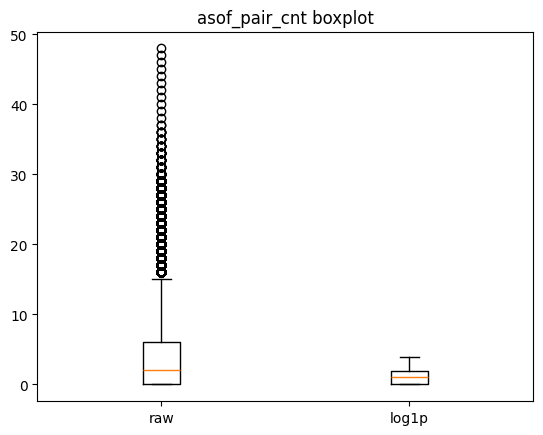

In [9]:
col = "asof_pair_cnt"
plt.boxplot([feat[col], np.log1p(feat[col])], labels=["raw", "log1p"])
plt.title(f"{col} boxplot"); plt.show()